![Imgur](https://i.imgur.com/h4PPC71.png)
#**19-modul. Unsupervised learning. Clustering**
# 19.8. Modul boʻyicha yakuniy amaliy vazifa. Mijozlarni xarajat turlariga qarab segmentlash

**Ushbu vazifa orqali siz:**

✔️ klasterlash;

✔️ maʼlumotlarni normallashtirish;

✔️ klaster tahlili;

✔️ vizualizatsiya kabi real data sayns loyihalari uchun zarur texnik ko‘nikmalarga ega bo‘lasiz.

## **Dataset: Wholesale Customers Data**  
- **Manba:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/wholesale+customers)  
- **Hajmi:** **22 KB**
- **Format:** CSV  
- **Tavsif:** bu dataset **ulgurji savdo mijozlarini** xarajatlar bo‘yicha klasterlash uchun ishlatiladi.  
  U quyidagi xarajat kategoriyalarini o‘z ichiga oladi:  
  - **channel** (mijoz turi: 1 – HoReCa (mehmonxona, restoran, kafelar) yoki 2 – chakana savdo)  
  - **region** (hudud: 1 – Lisbon, 2 – Oporto, 3 – boshqa)  
  - **fresh** (yangi mahsulotlarga sarf qilingan summa)  
  - **milk** (sut mahsulotlariga sarf qilingan summa)  
  - **grocery** (oziq-ovqat mahsulotlariga sarf qilingan summa)  
  - **frozen** (muzlatilgan mahsulotlarga sarf qilingan summa)  
  - **Detergents_Paper** (kimyoviy tozalash va qog‘oz mahsulotlari)  
  - **delicassen** (delikates mahsulotlar)  

---

### **Vazifa: mijozlarni xarajat turlariga qarab segmentlash**  
Maqsad – **mijozlarni xarajat qiladigan mahsulotlar bo‘yicha klasterlash va marketologlarga tavsiyalar berish**  

---

### **Klasterlash bosqichlari**  
1) **Maʼlumotlarni tayyorlash**  
   - `Channel` va `Region` ustunlarini olib tashlang yoki kodlang.  
   - Har bir xarajat ustunini **normalizatsiya qiling**.  

2) **K-means klasterlashni amalga oshirish**  
   - K-means yordamida mijozlarni **xarajat qilish odatlari** bo‘yicha segmentlarga ajrating.  

3) **Natijalarni vizualizatsiya qilish**  
   - **Pairplot yoki scatter plot** yordamida klasterlarni ko‘rsating.  
   - Har bir segmentning xarajatlar bo‘yicha o‘rtacha qiymatini diagrammada aks ettiring.

---

###*** ESLATMA**: *Ushbu amaliy vazifada siz oʻtmagan mavzulardan ham savollar va vazifalar boʻlishi mumkin! Bu savollarni mustaqil oʻrganishingiz kerak boʻladi. Bunday vazifalar mustaqil izlanish koʻnikmangizni oshirish uchun tayyorlandi!*

In [1]:
#javobni shu yerda yozing.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/Wholesale_customers_data.csv")
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
#barcha malumotlarni chiqarib olamiz
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nStatistical summary:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (440, 8)

Columns:
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None

Statistical summary:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000



Missing values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Duplicate rows: 0


In [4]:
#Datasetda missing value yo'q ekan lekin qayta tekshirdim
# Nusxa olib ishlaymiz
data = df.copy()

# Ustun nomlarini kichik harfga o'tkazib olamiz
data.columns = [col.lower() for col in data.columns]

#Duplicate satrlarni olib tashlash
data = data.drop_duplicates()

# Missing qiymatlar bo'lsa median bilan to'ldirish
for col in data.columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

print("Tozalangandan keyingi shape:", data.shape)
print(data.isnull().sum())

Tozalangandan keyingi shape: (440, 8)
channel             0
region              0
fresh               0
milk                0
grocery             0
frozen              0
detergents_paper    0
delicassen          0
dtype: int64


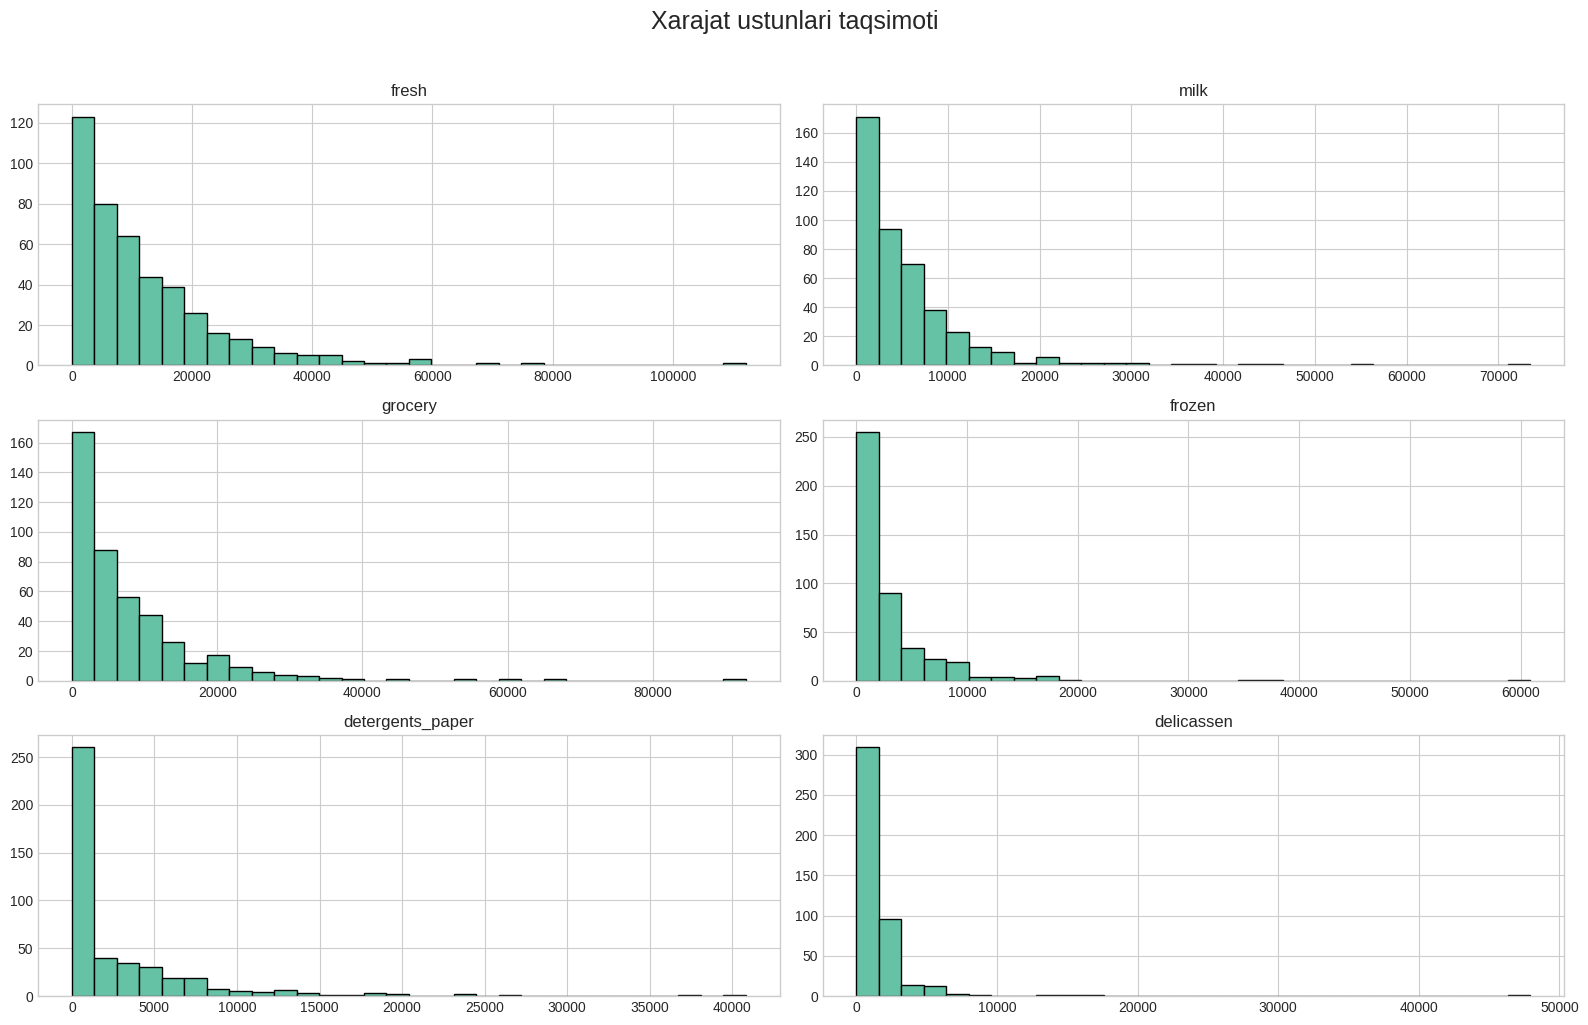

In [5]:
#EDA – taqsimot va outlierlarni ko‘rish
#histogramma
expense_cols = ['fresh', 'milk', 'grocery', 'frozen', 'detergents_paper', 'delicassen']

data[expense_cols].hist(figsize=(16, 10), bins=30, edgecolor='black')
plt.suptitle("Xarajat ustunlari taqsimoti", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

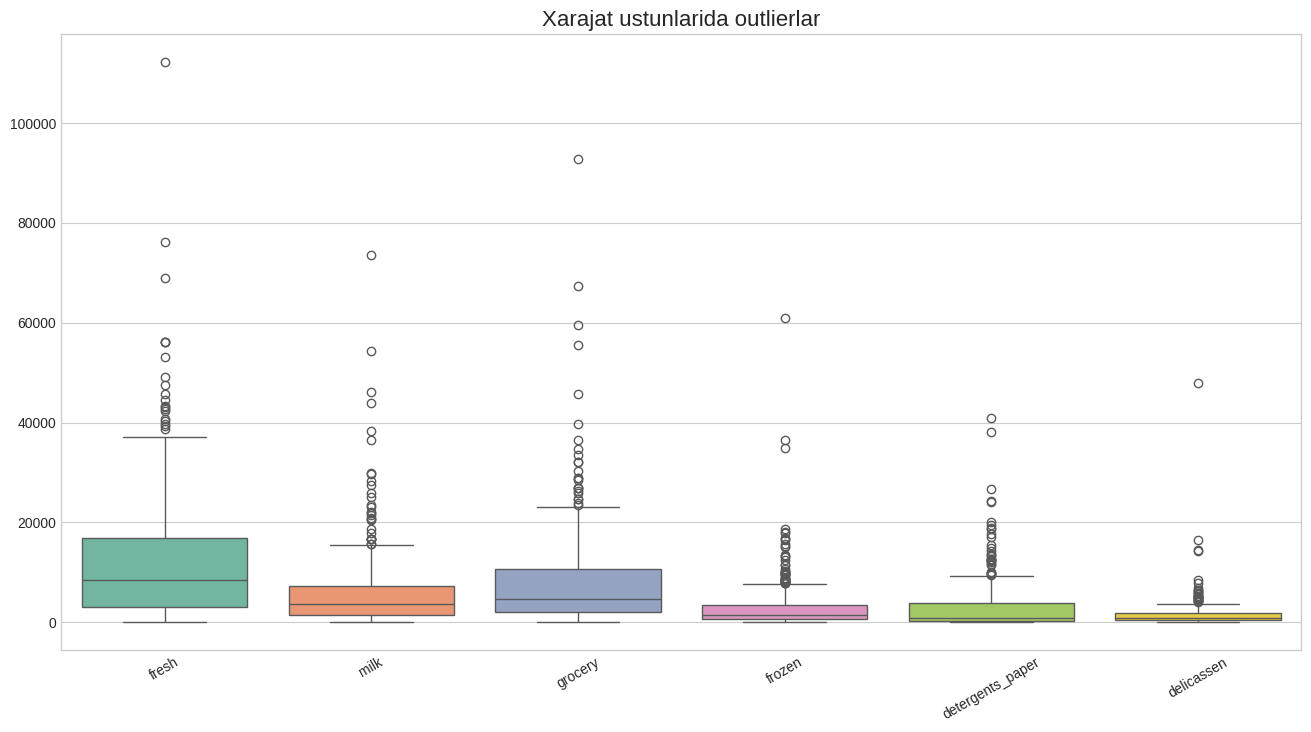

In [6]:
#boxplot
plt.figure(figsize=(16, 8))
sns.boxplot(data=data[expense_cols])
plt.title("Xarajat ustunlarida outlierlar", fontsize=16)
plt.xticks(rotation=30)
plt.show()

In [7]:
#channel va region olib tashlandi
X = data.drop(columns=['channel', 'region'])
X.head()

,fresh,milk,grocery,frozen,detergents_paper,delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [8]:
#standartscaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,fresh,milk,grocery,frozen,detergents_paper,delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


KMeans

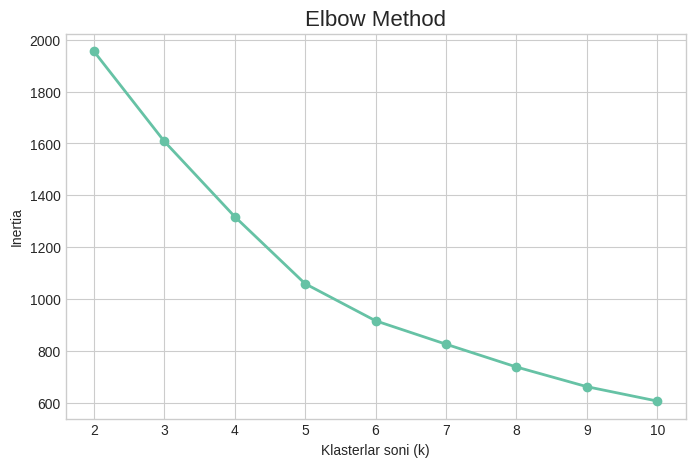

In [9]:
#KMeans uchun k ni topish
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linewidth=2)
plt.title("Elbow Method", fontsize=16)
plt.xlabel("Klasterlar soni (k)")
plt.ylabel("Inertia")
plt.show()

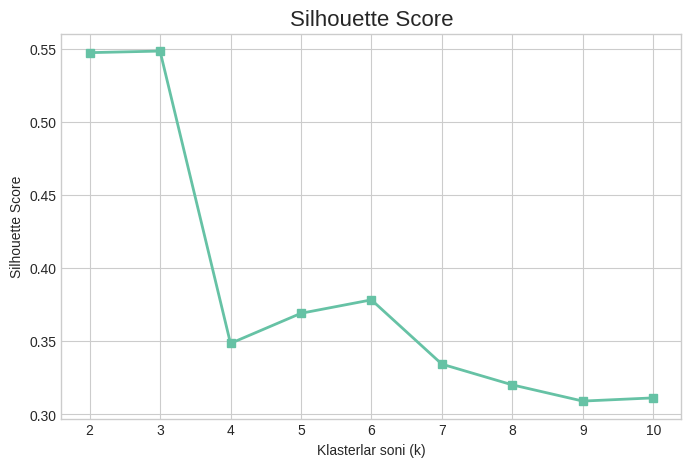

Eng yaxshi k: 3


In [10]:
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='s', linewidth=2)
plt.title("Silhouette Score", fontsize=16)
plt.xlabel("Klasterlar soni (k)")
plt.ylabel("Silhouette Score")
plt.show()

best_k = range(2, 11)[np.argmax(sil_scores)]
print("Eng yaxshi k:", best_k)

KMeans clustering

In [11]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

data_kmeans = data.copy()
data_kmeans['kmeans_cluster'] = kmeans_labels

data_kmeans.head()

,channel,region,fresh,milk,grocery,frozen,detergents_paper,delicassen,kmeans_cluster
0,2,3,12669,9656,7561,214,2674,1338,1
1,2,3,7057,9810,9568,1762,3293,1776,1
2,2,3,6353,8808,7684,2405,3516,7844,1
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1


Hierarchical clustering

In [12]:
hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

data_hier = data.copy()
data_hier['hier_cluster'] = hier_labels

data_hier.head()

,channel,region,fresh,milk,grocery,frozen,detergents_paper,delicassen,hier_cluster
0,2,3,12669,9656,7561,214,2674,1338,2
1,2,3,7057,9810,9568,1762,3293,1776,2
2,2,3,6353,8808,7684,2405,3516,7844,2
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1


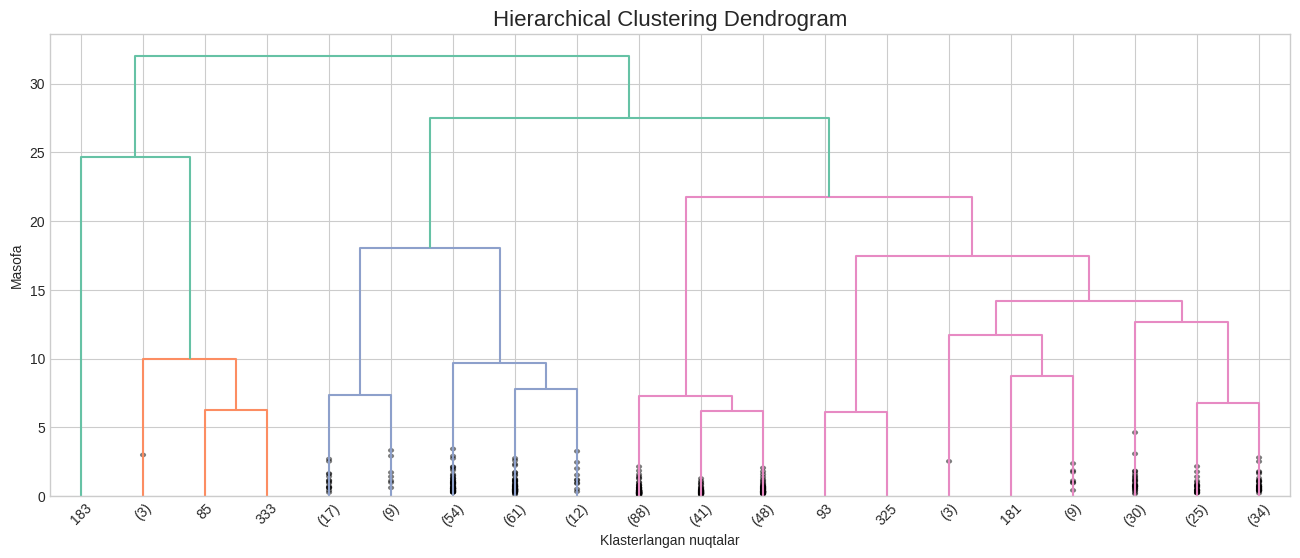

In [14]:
# grafigi
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(linked,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=45,
           leaf_font_size=10,
           show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram", fontsize=16)
plt.xlabel("Klasterlangan nuqtalar")
plt.ylabel("Masofa")
plt.show()

DBSCAN clustering

In [16]:
#eps va min_sample qiymatlar bilan dbscanni chiqarib olamiz
#-1 bo‘lsa, bu noise / outlier degani.
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

data_dbscan = data.copy()
data_dbscan['dbscan_cluster'] = db_labels

print("DBSCAN cluster labels:", np.unique(db_labels))
print(data_dbscan['dbscan_cluster'].value_counts())

DBSCAN cluster labels: [-1  0]
dbscan_cluster
 0    413
-1     27
Name: count, dtype: int64


In [17]:
#bizda 27 noise qaytdi, epsga boshqa qiymat berib qayta urinib ko'ramiz
for eps in [1.0, 1.2, 1.5, 1.8, 2.0]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    unique_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)
    print(f"eps={eps} -> clusters={unique_clusters}, noise={noise}")

eps=1.0 -> clusters=1, noise=47
eps=1.2 -> clusters=1, noise=38
eps=1.5 -> clusters=1, noise=27
eps=1.8 -> clusters=1, noise=16
eps=2.0 -> clusters=1, noise=13


In [18]:
dbscan = DBSCAN(eps=2.0, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

data_dbscan = data.copy()
data_dbscan['dbscan_cluster'] = db_labels

print("DBSCAN cluster labels:", np.unique(db_labels))
print(data_dbscan['dbscan_cluster'].value_counts())

DBSCAN cluster labels: [-1  0]
dbscan_cluster
 0    427
-1     13
Name: count, dtype: int64


In [20]:
#Barcha clustering natijalarini bir xil usulda chiroyli ko‘rsatish uchun PCA ishlatamiz.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['KMeans'] = kmeans_labels
pca_df['Hierarchical'] = hier_labels
pca_df['DBSCAN'] = db_labels

pca_df.head()

,PC1,PC2,KMeans,Hierarchical,DBSCAN
0,0.193291,-0.305100,1,2,0
1,0.434420,-0.328413,1,2,0
2,0.811143,0.815096,1,2,0
3,-0.778648,0.652754,1,1,0
4,0.166287,1.271434,1,1,0


KMeans, Hierarchical, DBSCAN grafiklari

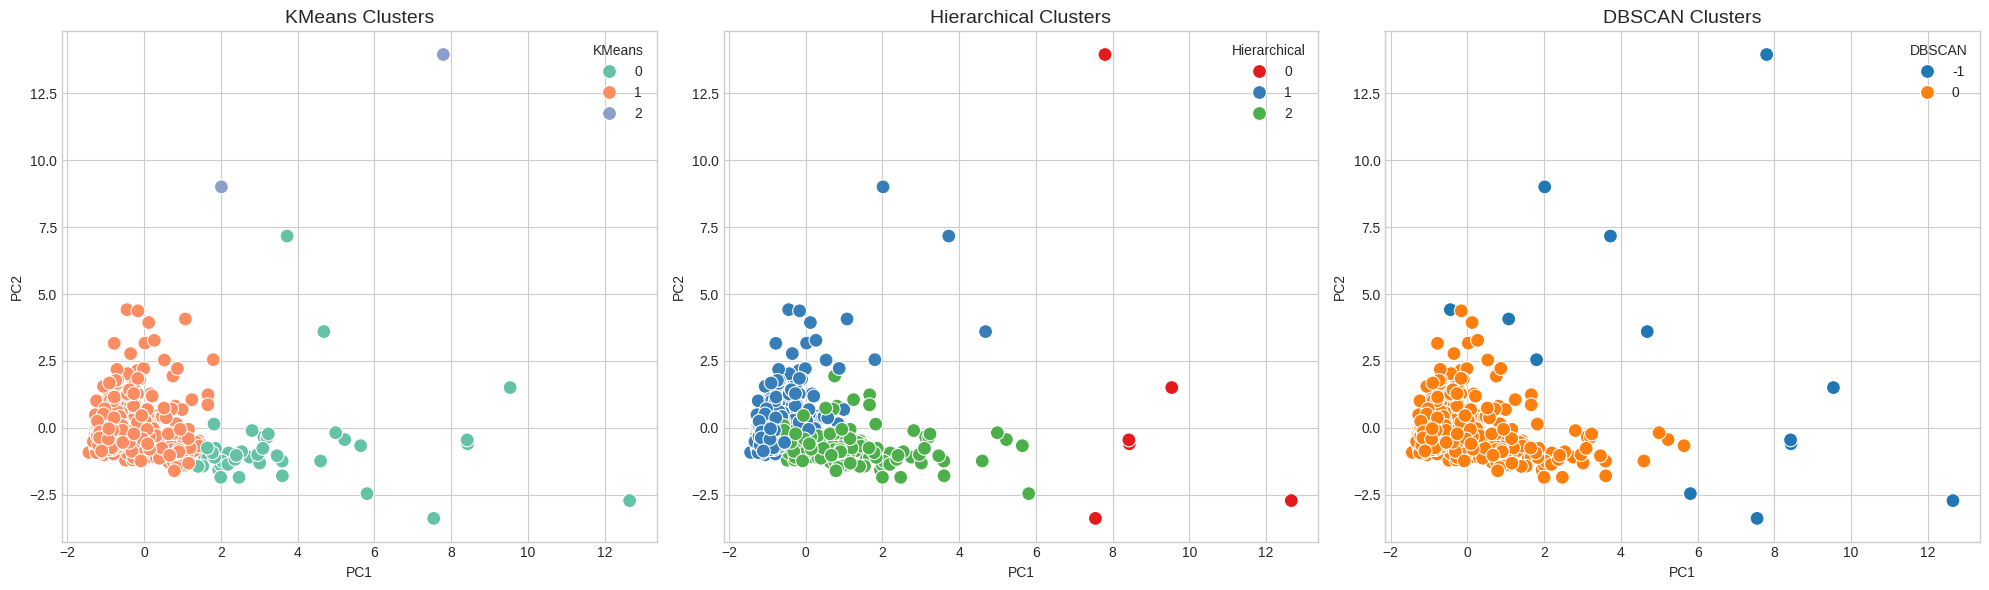

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='KMeans', palette='Set2', s=100, ax=axes[0])
axes[0].set_title("KMeans Clusters", fontsize=14)

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Hierarchical', palette='Set1', s=100, ax=axes[1])
axes[1].set_title("Hierarchical Clusters", fontsize=14)

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='DBSCAN', palette='tab10', s=100, ax=axes[2])
axes[2].set_title("DBSCAN Clusters", fontsize=14)

plt.tight_layout()
plt.show()

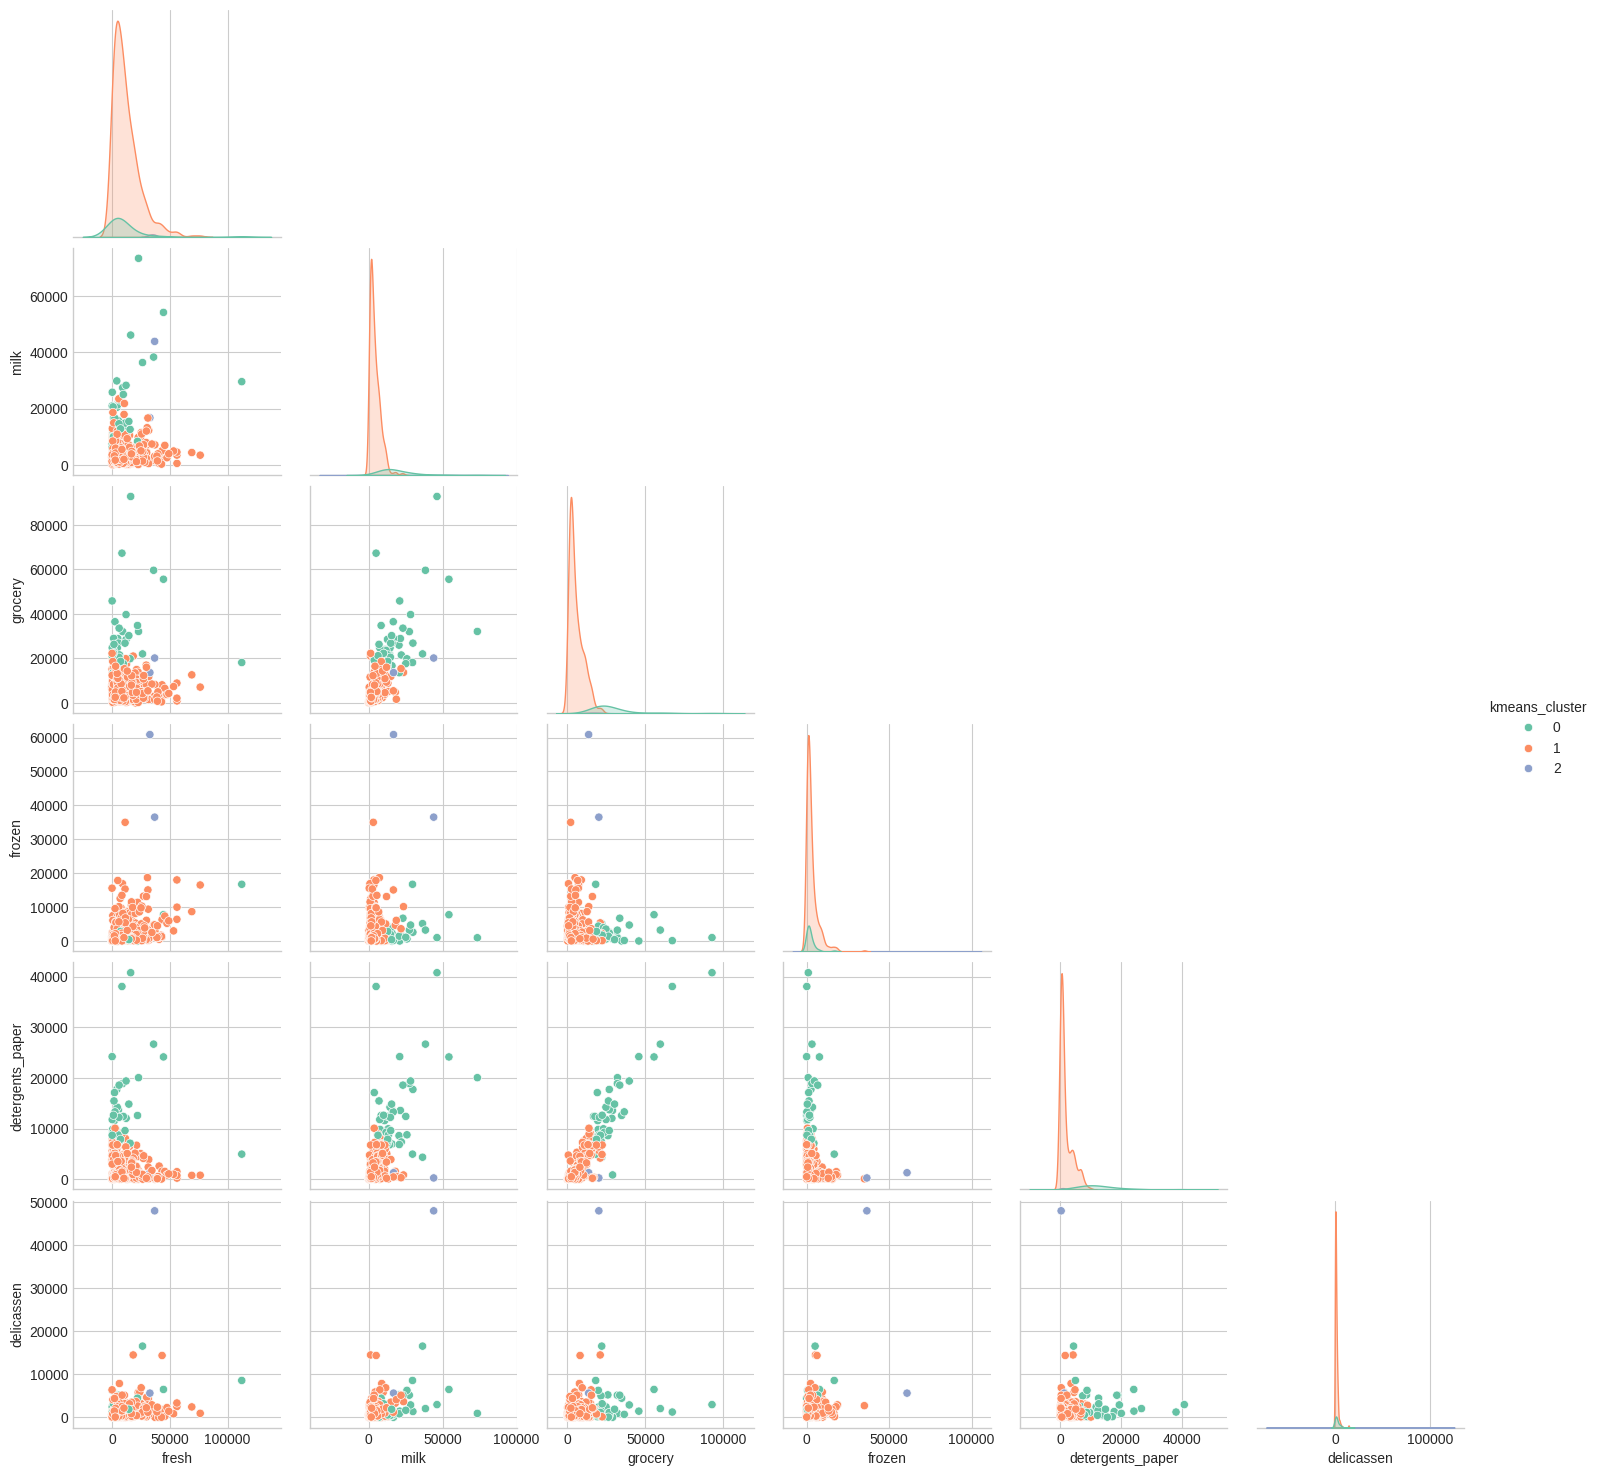

In [24]:
sample_data = data_kmeans.copy()

sns.pairplot(
    sample_data[['fresh', 'milk', 'grocery', 'frozen', 'detergents_paper', 'delicassen', 'kmeans_cluster']],
    hue='kmeans_cluster',
    palette='Set2',
    corner=True
)
plt.show()

,fresh,milk,grocery,frozen,detergents_paper,delicassen
kmeans_cluster,,,,,,
0,10440.93,19386.42,28656.09,2190.24,13327.80,2374.20
1,12062.91,4115.10,5534.97,2940.68,1696.17,1299.11
2,34782.00,30367.00,16898.00,48701.50,755.50,26776.00


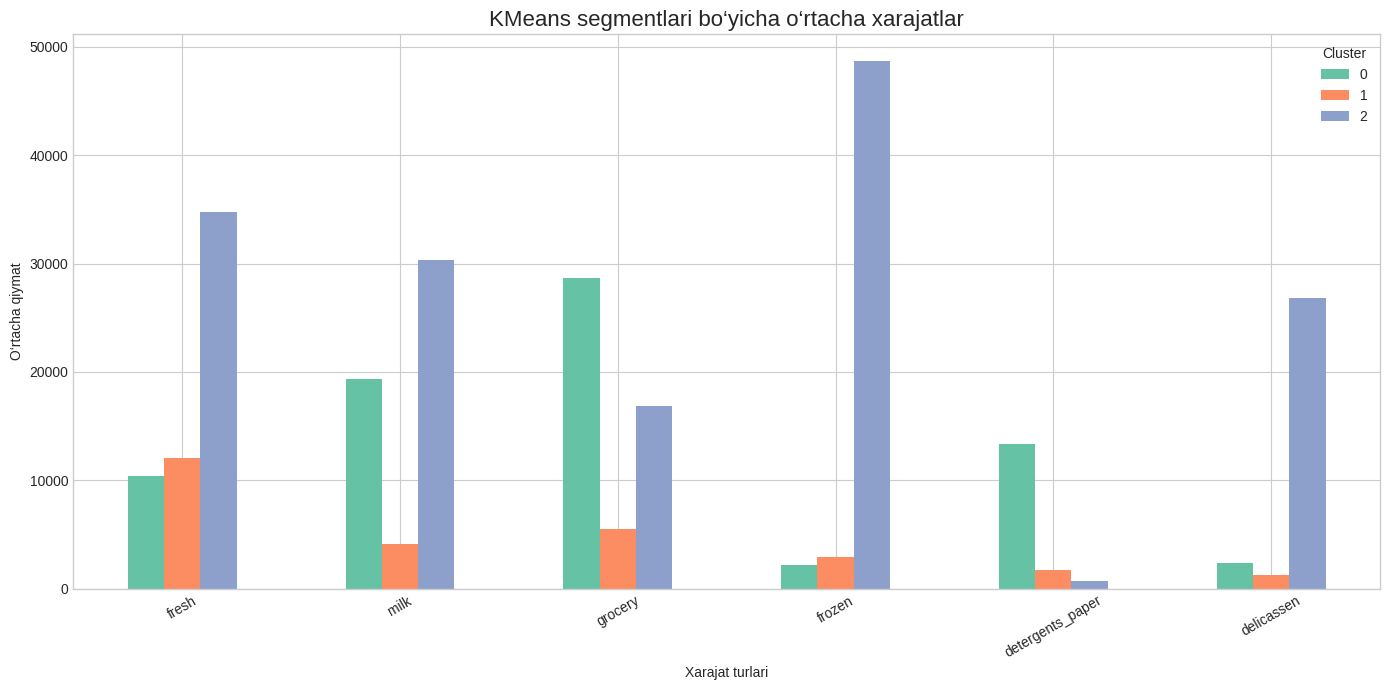

In [26]:
#Har bir klasterning o'rtacha harajatlari
kmeans_profile = data_kmeans.groupby('kmeans_cluster')[expense_cols].mean().round(2)
display(kmeans_profile)
kmeans_profile.T.plot(kind='bar', figsize=(14, 7))
plt.title("KMeans segmentlari bo‘yicha o‘rtacha xarajatlar", fontsize=16)
plt.xlabel("Xarajat turlari")
plt.ylabel("O‘rtacha qiymat")
plt.xticks(rotation=30)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [30]:
#Clustering sifatini taqqoslash
#KMeans
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)

# Hierarchical
hier_sil = silhouette_score(X_scaled, hier_labels)

print("KMeans silhouette score:", round(kmeans_sil, 4))
print("Hierarchical silhouette score:", round(hier_sil, 4))

# DBSCAN uchun -1 mavjud bo'lishi mumkin, shuning uchun tekshiramiz
if len(set(db_labels)) > 1 and len(set(db_labels)) - (1 if -1 in db_labels else 0) > 1:
    dbscan_sil = silhouette_score(X_scaled, db_labels)
    print("DBSCAN silhouette score:", round(dbscan_sil, 4))
else:
    print("DBSCAN uchun silhouette score hisoblab bo'lmadi (klasterlar yetarli emas).")

KMeans silhouette score: 0.5483
Hierarchical silhouette score: 0.2646
DBSCAN uchun silhouette score hisoblab bo'lmadi (klasterlar yetarli emas).


In [31]:
print(kmeans_profile)

                   fresh      milk   grocery    frozen  detergents_paper  \
kmeans_cluster                                                             
0               10440.93  19386.42  28656.09   2190.24          13327.80   
1               12062.91   4115.10   5534.97   2940.68           1696.17   
2               34782.00  30367.00  16898.00  48701.50            755.50   

                delicassen  
kmeans_cluster              
0                  2374.20  
1                  1299.11  
2                 26776.00  


KMeans natijasida mijozlar 3 ta segmentga ajratildi:

Cluster 0 – grocery, milk va detergents xarajatlari yuqori → retail mijozlar
Cluster 1 – barcha xarajatlar past → kam xarajat qiluvchi mijozlar
Cluster 2 – fresh, frozen va delicassen yuqori → HoReCa mijozlar
HO = Hotel (mehmonxona)
RE = Restaurant (restoran)
CA = Cafe (kafe)



Ushbu loyihada Wholesale Customers dataset asosida mijozlar xarajat turlariga qarab segmentlandi. Dastlab ma’lumotlar tozalandi va normallashtirildi, so‘ngra KMeans (hamda boshqa clustering usullari) yordamida mijozlar guruhlarga ajratildi.

Tahlil natijasida mijozlar xarid odatlariga qarab bir nechta aniq segmentlarga bo‘lindi. Ba’zi segmentlarda grocery, milk va detergents mahsulotlariga yuqori xarajat kuzatilsa, boshqalarida fresh va frozen mahsulotlarga ko‘proq e’tibor berilgan.



Ushbu segmentatsiya natijalari orqali:

har bir mijoz guruhining xarid xatti-harakatlari aniqlandi
marketing strategiyalarini segmentlarga moslashtirish imkoniyati yaratildi
resurslarni samarali taqsimlashga yordam beradi

Natijada kompaniya har bir segment uchun alohida yondashuv ishlab chiqib, savdoni oshirishi mumkin.